In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os, joblib, math, ast, random
from itertools import product

In [43]:
def loadBackup(base):
    df = []

    for path in os.listdir(base):
        index = int(path.split('_')[-1])
        
        with open(f'{base}/{path}/info.json', 'r', encoding='utf-8') as file:
            data = json.loads(file.read())
        
        name = data['model']
        data = data['info']
        data['name'] = name
        data['id'] = index
        df.append(data)

    return pd.DataFrame(df)


def loadModel(base, id):
    with open(f'{base}/model_{id}/info.json', 'r', encoding='utf-8') as file:
        data = json.loads(file.read())

    data['model'] = joblib.load(f'{base}/model_{id}/model.pkl')
    return data

### SISTEMA

In [44]:
df = loadBackup('Backup/System')
df

,r2,r2_adj,rmse,mae,name,id
0,0.947872,0.946539,39.143879,22.361166,linear_regression,2
1,0.947872,0.946539,39.143879,22.361166,linear_regression,1
2,0.947872,0.946539,39.143879,22.361166,linear_regression,3


In [45]:
data = loadModel('Backup/System', df.iloc[0].id)

sys_variables = data['variables']
print(sys_variables)

sys = data.get('model')
sys

['u', 'u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)']


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


### controlador

In [46]:
df = loadBackup('Backup/Controller')
df

,r2,r2_adj,rmse,mae,name,id
0,1.0,1.0,0.000091,0.000043,ridge,3


In [47]:
data = loadModel('Backup/Controller', df.iloc[0].id)

ctl_variables = data['variables']
print(ctl_variables)

ctl = data.get('model')
ctl

['u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)', 'error_integral', 'setpoint']


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.01
,fit_intercept,True
,copy_X,True
,max_iter,None


# CARREGANDO DADOS

In [48]:
N_STATES = sum(['u(n-' in var for var in sys_variables]) + 1 
N_STATES

5

In [49]:
class StatesUpdater:
    buffer  = None
    initial = 0
    size    = 0

    def __init__(self, size, initial=0.00):
        self.initial = initial
        self.size    = size
        self.buffer  = np.array([initial for i in range(size)])
        
    def update(self, value):
        for i in range(self.size-1, 0, -1):
            self.buffer[i] = self.buffer[i-1]

        self.buffer[0] = value
        return self.buffer
    
    def get(self, var='x'):
        data = {}
        data[var] = self.buffer[0]
        
        for i in range(1, self.size):
            data[f'{var}(n-{i})'] = self.buffer[i]

        return {key: float(val) for key, val in data.items()}


states = StatesUpdater(3)
for i in range(1, 5): states.update(i); print(states.get())

{'x': 1.0, 'x(n-1)': 0.0, 'x(n-2)': 0.0}
{'x': 2.0, 'x(n-1)': 1.0, 'x(n-2)': 0.0}
{'x': 3.0, 'x(n-1)': 2.0, 'x(n-2)': 1.0}
{'x': 4.0, 'x(n-1)': 3.0, 'x(n-2)': 2.0}


In [50]:
class System:
    def __init__(self, model, columns):
        self.sensor   = StatesUpdater(N_STATES)     
        self.actuator = StatesUpdater(N_STATES)   
        self.model = model
        self.cols  = columns

    def update(self, actuatorValue):
        self.actuator.update(actuatorValue)
        data = self.actuator.get('u')
        
        for i in range(1, N_STATES):
            data[f'x(n-{i})'] = self.sensor.buffer[i-1]
        
        response = self.model.predict(pd.DataFrame([data], columns=self.cols))[0]
        self.sensor.update(response)
        return self.sensor.buffer[0]
    
    def get(self):
        data = {}
        data.update(self.actuator.get('u'))
        data.update(self.sensor.get('x'))
        return data


class Controller:
    error_integral = 0
    
    def __init__(self, model, columns):
        self.sensor   = StatesUpdater(N_STATES)     
        self.actuator = StatesUpdater(N_STATES)   
        self.model = model
        self.cols  = columns

    def update(self, setpoint, sensorValue):
        self.sensor.update(sensorValue)
        self.error_integral += (setpoint - sensorValue)
        
        data = {}
        for i in range(1, N_STATES):
            data[f'u(n-{i})'] = self.actuator.buffer[i-1]
            data[f'x(n-{i})'] = self.sensor.buffer[i-1]
            
        data['setpoint'] = setpoint       
        
        if 'error_integral' in self.cols:
            data['error_integral'] = self.error_integral
            
        response = self.model.predict(pd.DataFrame([data], columns=self.cols))[0]
      
        if response < 0:
            response = 0

        if response > 255:
            response = 255

        self.actuator.update(response)
        return response

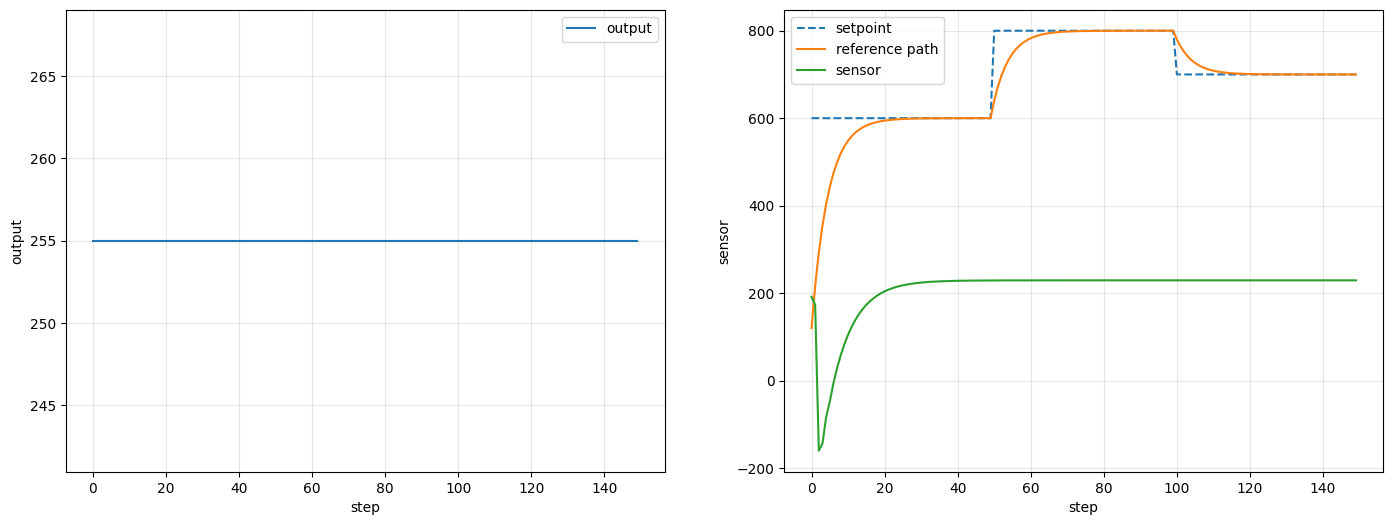

,setpoint,ref,u,x,error
0,600,120.000000,255,191.421644,408.578356
1,600,216.000000,255,173.436698,426.563302
2,600,292.800000,255,-160.452057,760.452057
3,600,354.240000,255,-143.912352,743.912352
4,600,403.392000,255,-83.829495,683.829495
...,...,...,...,...,...
145,700,700.003484,255,229.163911,470.836089
146,700,700.002788,255,229.163911,470.836089
147,700,700.002230,255,229.163911,470.836089
148,700,700.001784,255,229.163911,470.836089


In [51]:
system     = System(sys, sys_variables)          
controller = Controller(ctl, ctl_variables)  
setpointPath = [600]*50 + [800]*50 + [700]*50 

history = []
x = 0 
ref = 0
alpha = 0.8 # path filter pra suavizar degraus

for setpoint in setpointPath:
    ref = alpha * ref + (1 - alpha) * setpoint
    u = controller.update(ref, x)
    x = system.update(u)
    history.append({'setpoint': setpoint, 'ref': ref, 'u': u, 'x': x, 'error': setpoint - x})

df = pd.DataFrame(history)

plt.figure(figsize=(17, 6))
plt.subplot(1, 2, 1)
plt.plot(df.u, label='output')
plt.xlabel('step'); plt.ylabel('output'); plt.legend()
plt.grid(alpha=.3)

plt.subplot(1, 2, 2)
plt.plot(df.setpoint, label='setpoint', linestyle='--')
plt.plot(df.ref, label='reference path')
plt.plot(df.x, label='sensor')
plt.xlabel('step'); plt.ylabel('sensor')
plt.grid(alpha=.3); plt.legend()

plt.show()
display(df)